# Analysis of hierarchical network structure in auditory connectome

***bold text is GJG annotation** \
cxns_noDup = connectivity matrix. 

Each entry is # of synapses between a single neuron pair. Presynaptic partner goes down the rows, postsynaptic partner goes across the columns. **From the looks of the visualized matrix, the graph is directed.**
    
lineNames_nosub = the name of each cell type (or split-GAL4 line). Each cell type contains 1 to >100 individual neurons, and some cell types are split into subtypes (ie, 'B1-1, 'B1-2', etc)

neuronNames = name of each neuron in the connectivity matrix. Each name is unique. The beginning part of the name indicates which cell type the neuron is from (ie, '16374_L1' is from cell type 16374, and 'WV-WV-1_L1' is from cell type WV-WV). **The appended string appears to indicate left or right and instance number**

I have ignored the diagonal values (which would represent autapses) by inserting NaNs. In my connectivity diagram, I have also ignored connections between individual neurons that belong to the same cell type due to the high rate of false positives of the automatically detected synapses in these cases. **I question some of these choices and might try a version with autapses either set to zero or non-zero.**

For the current connectome figure, I set a threshold of 15 synapses between one single pair of neurons to indicate a likely connection, and then required at least 3% of all possible connections between two cell types (in one direction) to cross this threshold. **Not sure why this was necessary.** 

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy import stats
import sys

from aux import loadmat_h5
from disp import set_font_size



## Old data
**Don't use these cells. I don't have this data. Just keeping it here to reference.**

In [ ]:
# DATA_FILE = 'data/christa/allAudNeurons_connMat_noDupSyn.mat'
DATA_FILE = 'data/christa/allAudNeurons_connMat_noDupSyn_cleftFilt_20210603.mat'  # updated

**The original data was not available through the link in the README, but seeing it printed below is helpful for figuring out what it should look like. According to the aux.py script, these objects are Numpy arrays. My first task will be to create dummy numpy arrays to test the hierarchical analyses. Notice that the only data needed for the analysis is a numpy connectivity matrix. In fact, that connectivity matrix is turned into a networkx graph (directed acyclic) and given as input to the hierarchy anlyses.**

In [2]:
data = loadmat_h5(DATA_FILE)
print(data.keys())

w = data['cxns_noDup']
print(w)

dict_keys(['cxns_noDup', 'lineNames_nosub', 'neuronClasses', 'neuronNames'])
[[nan  0.  0. ...  0.  0.  0.]
 [ 0. nan  1. ...  0.  0.  0.]
 [ 0.  1. nan ...  0.  0.  0.]
 ...
 [ 0.  0.  0. ... nan  1.  3.]
 [ 0.  0.  0. ...  5. nan  5.]
 [ 0.  0.  0. ...  1.  0. nan]]


In [3]:
data['lineNames_nosub']

array([['A1', 'A2', 'B1-1', 'B2', 'GF', 'WED-VLP-1', 'WV-WV-1',
        '16374-27885', '27885', '27936', '36007', '37007', '40303',
        '41728-41730', '41730', '43299', '21914', '29146', '35996',
        '47261', '23281', '27932', '29136', '35916', '36012', '38918',
        '40316', '41739', '45858', 'vpoEN', 'vpoIN', 'pMN1', 'pMN2',
        'pC2la', 'pC1al']], dtype=object)

In [4]:
data['neuronNames'].T

array([['A1_L1', 'A1_L2', 'A1_L3', 'A1_R1', 'A1_R2', 'A2_L', 'A2_R',
        'B1-1_L1', 'B1-1_L2', 'B1-1_L3', 'B1-1_L4', 'B1-1_L5', 'B1-1_L6',
        'B1-1_R1', 'B1-1_R2', 'B1-1_R3', 'B1-1_R4', 'B1-1_R5', 'B1-1_R6',
        'B1-2_L1', 'B1-2_L2', 'B1-2_L3', 'B1-2_L4', 'B1-2_L5', 'B1-2_L6',
        'B1-2_L7', 'B1-2_L8', 'B1-2_R1', 'B1-2_R2', 'B1-2_R3', 'B1-2_R4',
        'B1-2_R5', 'B1-2_R6', 'B1-2_R7', 'B1-2_R8', 'B1-3_L1', 'B1-3_L2',
        'B1-3_L3', 'B1-3_L4', 'B1-3_R1', 'B1-3_R2', 'B1-3_R3', 'B1-3_R4',
        'B1-4_L1', 'B1-4_L2', 'B1-4_L3', 'B1-4_L4', 'B1-4_L5', 'B1-4_L6',
        'B1-4_L7', 'B1-4_R1', 'B1-4_R2', 'B1-4_R3', 'B1-4_R4', 'B1-4_R5',
        'B1-4_R6', 'B1-4_R7', 'B1-u_L1', 'B1-u_L2', 'B1-u_L3', 'B1-u_L4',
        'B1-u_L5', 'B1-u_L6', 'B1-u_L7', 'B1-u_L8', 'B1-u_L9',
        'B1-u_L10', 'B1-u_L11', 'B1-u_L12', 'B1-u_L13', 'B1-u_L14',
        'B1-u_L15', 'B1-u_L16', 'B1-u_L17', 'B1-u_L18', 'B1-u_L19',
        'B1-u_L20', 'B1-u_L21', 'B1-u_L22', 'B1-u_L23', 'B1-u_L24'

**There are about 500 neurons in this original dataset but the new data Christa shared has 910. That's mainly because her new data includes the JONs and a few new instances of other cell types.**

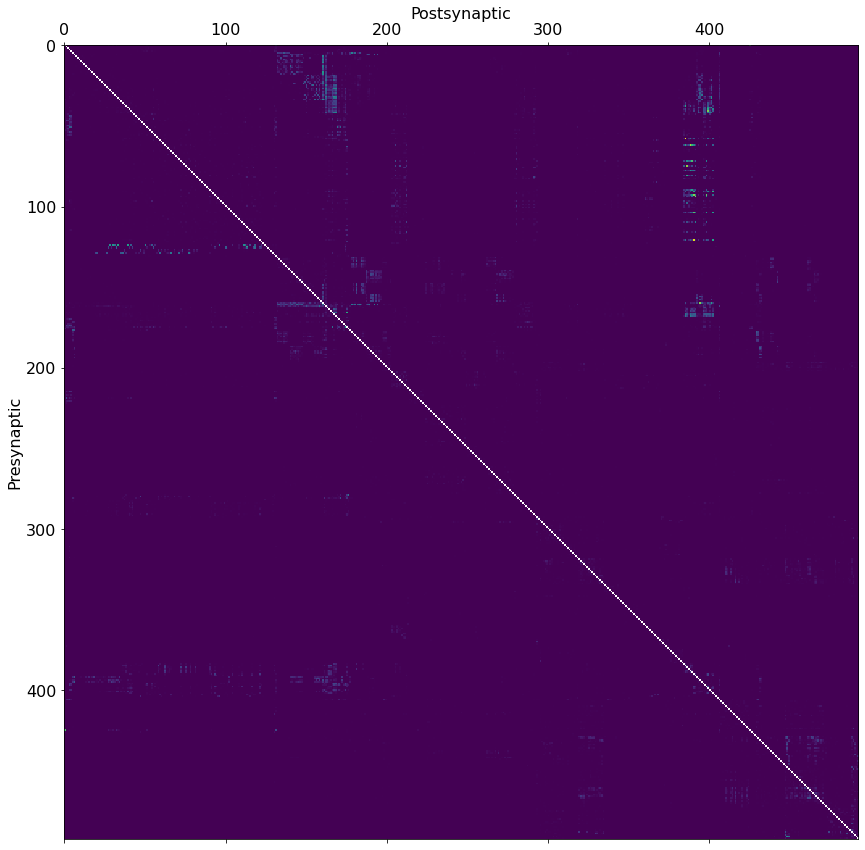

In [5]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), tight_layout=True)
ax.matshow(w)
ax.set_xlabel('Postsynaptic')
ax.set_ylabel('Presynaptic')
ax.xaxis.set_label_position('top')

set_font_size(ax, 16)

## New data
Loading and analyzing new data from [Christa's spreadsheet](https://docs.google.com/spreadsheets/d/1w24pivA9woop5CX0ltbse-LACqm5WkSS7HC12tKFarU/edit?usp=sharing). 

In [3]:
# load the new data from the CSV file
new_data = pd.read_csv('new_data/Auditory neurons Lockwood et al PRIMARY LIST - Sheet1.csv')
new_data

,Neuron name (Baker et al 2022),Cell type (Baker et al 2022),Neuron name (Lockwood et al),Cell type (Lockwood et al),Coordinates,Codex June 2024,HB type,FAFB NT,BANC NT,NT2026 (FAFB and BANC),JOA (L+R) influence score,JOB (L+R) influence score,JOA L influence,JOB L influence
0,A1_L1,A1,A1_R1,A1,[160548 55409 4977],720575940631693610,AMMC-A1,inconclusive,inconclusive,inconclusive,NaN,NaN,NaN,NaN
1,A1_L2,A1,A1_R2,A1,[161229 56723 4921],720575940631200327,AMMC-A1,inconclusive,inconclusive,inconclusive,NaN,NaN,NaN,NaN
2,A1_L3,A1,A1_R3,A1,[159857 56701 5018],720575940618522433,AMMC-A1,inconclusive,inconclusive,inconclusive,NaN,NaN,NaN,NaN
3,A1_R1,A1,A1_L1,A1,[105496 54286 5405],720575940612001489,AMMC-A1,inconclusive,inconclusive,inconclusive,NaN,NaN,NaN,NaN
4,A1_R2,A1,A1_L2,A1,[105654 55604 5474],720575940616313942,AMMC-A1,inconclusive,inconclusive,inconclusive,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
904,NaN,NaN,JO-B_L162,JO-B,NaN,720575940631670584,NaN,NaN,NaN,Ach,NaN,NaN,NaN,NaN
905,NaN,NaN,JO-B_L163,JO-B,NaN,720575940617244049,NaN,NaN,NaN,Ach,NaN,NaN,NaN,NaN
906,NaN,NaN,JO-B_L164,JO-B,NaN,720575940617407929,NaN,NaN,NaN,Ach,NaN,NaN,NaN,NaN
907,NaN,NaN,JO-B_L165,JO-B,NaN,720575940620257216,NaN,NaN,NaN,Ach,NaN,NaN,NaN,NaN


In [4]:
# get ids from the new data
new_data_ids = new_data['Codex June 2024'].to_list()

In [5]:
# load connections 
connections = pd.read_csv('/Users/ggutierr/Documents/FlyWireData/connections_princeton.csv')

In [6]:
# condense the neuropil connections
simple_connections = connections.groupby(['pre_root_id', 'post_root_id']).agg({'syn_count': 'sum'}).reset_index()

In [7]:
# get connections for the new data ids
new_data_conns = simple_connections[simple_connections['pre_root_id'].isin(new_data_ids) | simple_connections['post_root_id'].isin(new_data_ids)]

In [8]:
# load cell types
cell_types = pd.read_csv('/Users/ggutierr/Documents/FlyWireData/consolidated_cell_types.csv')

In [9]:
cell_types

,root_id,primary_type,additional_type(s)
0,720575940596125868,T5c,NaN
1,720575940597856265,Tm16,NaN
2,720575940597944841,Tm7,CB3851
3,720575940598267657,TmY15,NaN
4,720575940599333574,Tm1,NaN
...,...,...,...
137672,720575940661335681,CB0180,NaN
137673,720575940661336193,TmY3,NaN
137674,720575940661337217,KCab-p,NaN
137675,720575940661338497,CB0904,NaN


In [10]:
# merge cell types with the new data connections
new_data_connections = new_data_conns.copy()
new_data_connections = new_data_connections.merge(cell_types[['root_id', 'primary_type']], left_on='pre_root_id', right_on='root_id', how='left').rename(columns={'primary_type': 'pre_type'}).drop(columns=['root_id'])
new_data_connections = new_data_connections.merge(cell_types[['root_id', 'primary_type']], left_on='post_root_id', right_on='root_id', how='left').rename(columns={'primary_type': 'post_type'}).drop(columns=['root_id'])

In the original version of this analysis, the authors put NaN along the diagonal of the connectivity matrix and also made connections between neurons of the same type go to zero. 

In [11]:
# set connections between neurons of the same type equal to zero
new_data_connections.loc[new_data_connections['pre_type'] == new_data_connections['post_type'], 'syn_count'] = 0

In [12]:
# make a square numpy array using the same root ID order for rows and columns
root_ids = pd.Index(new_data_ids).unique()

w = (
    new_data_connections[['pre_root_id', 'post_root_id', 'syn_count']]
    .pivot_table(
        index='pre_root_id',
        columns='post_root_id',
        values='syn_count',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(index=root_ids, columns=root_ids, fill_value=0)
    .to_numpy()
)

In [13]:
w.shape

(909, 909)

In [14]:
# put NaN values in the diagonal of the matrix
# Convert to floating point before inserting NaN values.
w = w.astype(float, copy=False)
np.fill_diagonal(w, np.nan)

In [15]:
w

array([[nan,  0.,  0., ...,  0.,  0.,  0.],
       [ 0., nan,  0., ...,  0.,  0.,  0.],
       [ 0.,  0., nan, ...,  0.,  0.,  0.],
       ...,
       [ 0.,  0.,  0., ..., nan,  0.,  0.],
       [ 0.,  0.,  0., ...,  0., nan,  0.],
       [ 0.,  0.,  0., ...,  0.,  0., nan]])

In [16]:
fig, ax = plt.subplots(1, 1, figsize=(12, 12), tight_layout=True)
ax.matshow(w)
ax.set_xlabel('Postsynaptic')
ax.set_ylabel('Presynaptic')
ax.xaxis.set_label_position('top')

set_font_size(ax, 16)

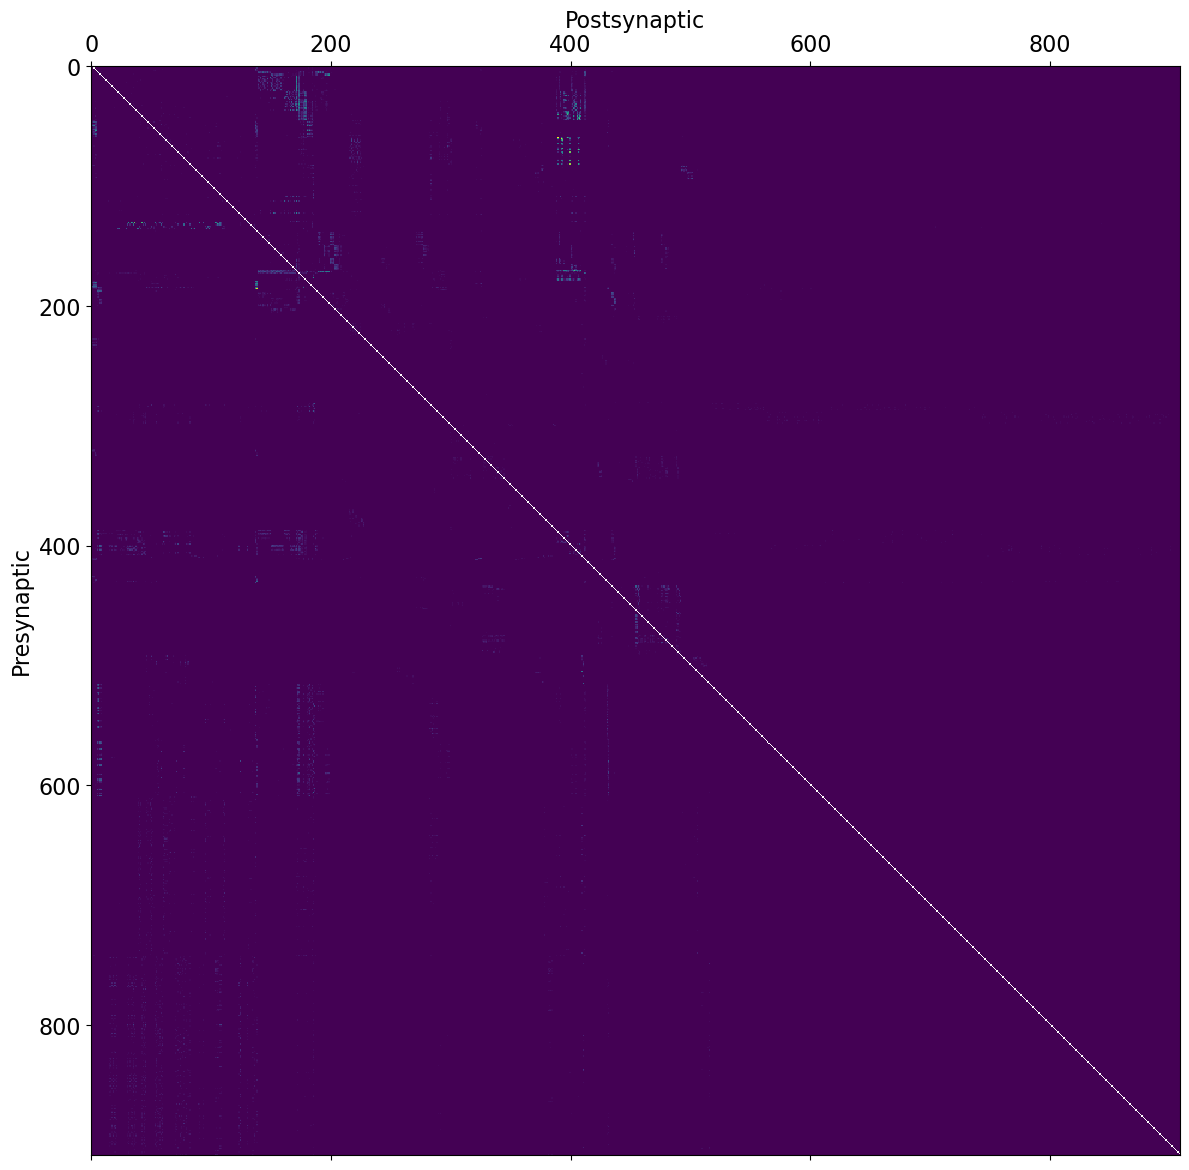

In [17]:
plt.show()

## Analyses

Metrics from [corominasmurtra2013origins](https://www.pnas.org/content/110/33/13316) (Rodriguez-Caso) PNAS. On the origins of hierarchy in complex networks. **This is the important part for us. Make a new notebook with these functions and test them on dummy data. Run more extensive tests than were done here. From there, build out another notebook that analyzes the new, expanded auditory data.**

In [18]:
def get_gc(g):
    """Return graph condensation."""
    scc = list(nx.strongly_connected_components(g))
    gc = nx.algorithms.components.condensation(g, scc=scc)
    return gc, scc

def calc_treeness(gc):
    """Return treeness."""
    
    assert nx.is_directed_acyclic_graph(gc)
    
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
    
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0., 0., 0.
   
    h_fwds = []
    for v in max_nodes:
        # count all paths from v to each min_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path from v (to self), so 0 entropy
            continue
            
        p_paths = np.array([np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths])  # prob of path is product of all out_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_fwds.append(stats.entropy(p_paths, base=2))
        
    h_fwd = np.sum(h_fwds)/len(max_nodes)
    
    h_baks = []
    for u in min_nodes:
        # count all paths to u from each max_node
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for v in max_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            h_fwds.append(0)  # only one path to u (from self), so 0 entropy
            continue
    
        p_paths = np.array([np.prod([1/k_ins[u_] for u_ in path[1:]]) for path in paths])  # prob of path is product of all in_degrees along path
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        h_baks.append(stats.entropy(p_paths, base=2))
        
    h_bak = np.sum(h_baks)/len(min_nodes)
    
    return (h_fwd - h_bak) / max(h_fwd, h_bak), h_fwd, h_bak


def calc_feedforwardness(gc):
    """Return feedforwardness"""
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
    
    if len(max_nodes) == len(min_nodes) == len(gc):
        return 0.
    
    alph = {i: len(gc.nodes[i]['members']) for i in gc.nodes()}
    
    paths_all = []
    p_paths_all = []

    for v in max_nodes:
#         paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if nx.has_path(gc, v, u)], [])
        paths = sum([list(nx.all_simple_paths(gc, v, u)) for u in min_nodes if (u != v and nx.has_path(gc, v, u))], [])
        
        if len(paths) == 0:
            continue
            
        p_paths = [np.prod([1/k_outs[v_] for v_ in path[:-1]]) for path in paths]
        
        np.testing.assert_almost_equal(np.sum(p_paths), 1)
        p_paths /= np.sum(p_paths)
        
        paths_all.extend(paths)
        p_paths_all.extend(p_paths)
        
    p_paths_all = np.array(p_paths_all) / len(max_nodes)
    
    ffs = []
    
    for path in paths_all:
        
        ffs.append(len(path)/np.sum([alph[i] for i in path]))
    
    return np.mean(ffs)

def calc_orderability(gc):
    """Return orderability."""
    k_ins = gc.in_degree()
    k_outs = gc.out_degree()
    
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    min_nodes = np.array([v for v, k_out in k_outs if k_out == 0])
       
    alph = np.array([len(gc.nodes[v]['members']) for v in gc.nodes() if (k_ins[v] or k_outs[v])])
    
    return np.sum(alph == 1)/alph.sum()

Test graphs

In [3]:
adj_a = np.array([
    [0, 1, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0],
])

adj_b = np.array([
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 1],
    [0, 0, 0, 0, 0, 0, 0],
])

adj_c = np.array([
    [0, 0, 1, 0, 0],
    [0, 0, 1, 0, 0],
    [0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0],
])

adj_d = np.array([
    [0, 1, 1, 1, 0, 0, 0, 0, 0, 0],
    [1, 0, 0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
])

g_a = nx.from_numpy_array(adj_a, create_using=nx.DiGraph)
g_b = nx.from_numpy_array(adj_b, create_using=nx.DiGraph)
g_c = nx.from_numpy_array(adj_c, create_using=nx.DiGraph)
g_d = nx.from_numpy_array(adj_d, create_using=nx.DiGraph)

In [4]:
gc_a, scc_a = get_gc(g_a)
gc_b, scc_b = get_gc(g_b)
gc_c, scc_c = get_gc(g_c)
gc_d, scc_d = get_gc(g_d)

In [5]:
t_a = calc_treeness(gc_a)[0]
t_b = calc_treeness(gc_b)[0]
t_c = calc_treeness(gc_c)[0]
t_d = calc_treeness(gc_d)[0]

f_a = calc_feedforwardness(gc_a)
f_b = calc_feedforwardness(gc_b)
f_c = calc_feedforwardness(gc_c)
f_d = calc_feedforwardness(gc_d)

o_a = calc_orderability(gc_a)
o_b = calc_orderability(gc_b)
o_c = calc_orderability(gc_c)
o_d = calc_orderability(gc_d)

In [6]:
print(f'T(A) = {t_a}, F(A) = {f_a}, O(A) = {o_a}')
print(f'T(B) = {t_b}, F(A) = {f_b}, O(B) = {o_b}')
print(f'T(C) = {t_c}, F(A) = {f_c}, O(C) = {o_c}')
print(f'T(D) = {t_d}, F(A) = {f_d}, O(D) = {o_d}')

T(A) = 1.0, F(A) = 1.0, O(A) = 1.0
T(B) = -1.0, F(A) = 1.0, O(B) = 1.0
T(C) = 0.0, F(A) = 1.0, O(C) = 1.0
T(D) = 1.0, F(A) = 0.625, O(D) = 0.5


Should be:

`T(A) = 1.0, F(A) = 1.0, O(A) = 1.0`

`T(B) = -1.0, F(A) = 1.0, O(B) = 1.0`

`T(C) = 0.0, F(A) = 1.0, O(C) = 1.0`

`T(D) = 1.0, F(A) = 0.625, O(D) = 0.5`

Analyze fly graph \
**The first code block looks like a little test. These 2 lines of code precede almost every analysis. They create a networkx graph from the numpy array connectivity matrix, then create a condensed graph.**
```
g_fly_test = nx.from_numpy_array(adj_fly_test, create_using=nx.DiGraph)
gc_fly_test, scc_fly_test = get_gc(g_fly_test)
```
**The next code block does the same thing but it iterates over a range of synapse thresholds and puts the results in a dataframe.**

In [19]:
adj_fly_test = (w >= 5)
g_fly_test = nx.from_numpy_array(adj_fly_test, create_using=nx.DiGraph)
gc_fly_test, scc_fly_test = get_gc(g_fly_test)

t_fly_test = calc_treeness(gc_fly_test)[0]
f_fly_test = calc_feedforwardness(gc_fly_test)
o_fly_test = calc_orderability(gc_fly_test)

In [ ]:
# unadulterated w
t_fly_test, f_fly_test, o_fly_test

(0.411438983922714, 0.014446989745955712, 0.3507549361207898)

In [20]:
t_fly_test, f_fly_test, o_fly_test

(0.370608618451825, 0.014278862293709178, 0.3875878220140515)

In [21]:
try:
    df_tfo_fly = pd.read_csv('new_data/fly_hierarchy_metrics.csv')
except:
    # loop over num synapses used to define a connection
    min_syns = np.arange(15) + 1

    ts_fly = np.nan * np.zeros(len(min_syns))
    fs_fly = np.nan * np.zeros(len(min_syns))
    os_fly = np.nan * np.zeros(len(min_syns))
    alphs_all = []

    for cms, min_syn in enumerate(min_syns):
        sys.stdout.write('.')
        adj_fly = w >= min_syn

        g_fly = nx.from_numpy_array(adj_fly, create_using=nx.DiGraph)
        gc_fly, scc_fly = get_gc(g_fly)

        t_fly = calc_treeness(gc_fly)[0]
        f_fly = calc_feedforwardness(gc_fly)
        o_fly = calc_orderability(gc_fly)

        ts_fly[cms] = t_fly
        fs_fly[cms] = f_fly
        os_fly[cms] = o_fly

        alphs_all.append([len(scc) for scc in scc_fly])

    dicts_tfo_fly = [
        {'min_syn': min_syn, 'treeness': t_fly, 'feedforwardness': f_fly, 'orderability': o_fly, 'num_scc': len(alphs)}
        for min_syn, t_fly, f_fly, o_fly, alphs in zip(min_syns, ts_fly, fs_fly, os_fly, alphs_all)
    ]
    df_tfo_fly = pd.DataFrame(columns=['min_syn', 'treeness', 'feedforwardness', 'orderability', 'num_scc'], data=dicts_tfo_fly)
    df_tfo_fly.to_csv('new_data/fly_hierarchy_metrics.csv', index=False)

In [22]:
fig, axs = plt.subplots(2, 1, figsize=(10, 6), tight_layout=True)
axs[0].plot(df_tfo_fly['min_syn'], df_tfo_fly['treeness'], c='k', lw=3)
axs[0].plot(df_tfo_fly['min_syn'], df_tfo_fly['feedforwardness'], c='g', lw=3)
axs[0].plot(df_tfo_fly['min_syn'], df_tfo_fly['orderability'], c='b', lw=3)

axs[0].set_xlabel('Min # synapses per connection')
axs[0].set_ylabel('T, F, O')
axs[0].legend(['Treeness', 'Feedforwardness', 'Orderability'], ncol=3)
axs[0].grid()

axs[1].plot(df_tfo_fly['min_syn'], df_tfo_fly['num_scc'], c='k', lw=3)
axs[1].set_xlabel('Min # synapses per connection')
axs[1].set_ylabel('# SCCs')

set_font_size(axs, 16)

fig.savefig('plots/hierarchy_vs_synapses.png')

**The treeness looks the most different for the new data while the other metrics are comparable to those for the old data.**

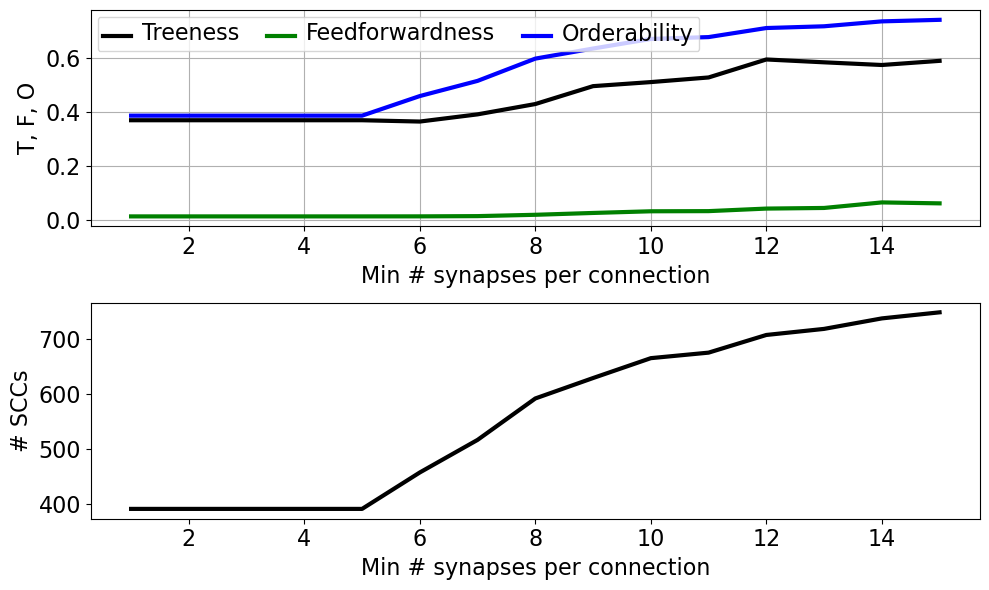

In [23]:
plt.show()

# Draw condensed fly graph
**This code block appears to mainly be for visualization of the condensed graph. I may need to dissect it to understand how to interpret the visual. I had copilot add the comments which I read through and they appear to make sense.**

**Since the synapses are all thresholded at 5 anyway, there is no need to start min_syns any lower than that.**

In [ ]:
min_syns_rand = [1, 5, 10]
#min_syns_rand = [5, 10]

for cs, min_syn in enumerate(min_syns_rand):
    # Threshold the connectivity matrix so only strong enough connections remain.
    g_fly = nx.from_numpy_array(w >= min_syn, create_using=nx.DiGraph)
    
    # Collapse each strongly connected component into a single node to obtain a DAG.
    gc_fly, scc_fly = get_gc(g_fly)
    
    # The condensed graph should be acyclic, which is required for the hierarchy layout.
    assert nx.is_directed_acyclic_graph(gc_fly)
    
    # List the nodes in the condensed graph for later positioning and plotting.
    node_list = np.array(list(gc_fly.nodes()))
    
    # Degree information is used to identify roots and leaves of the DAG.
    k_ins = gc_fly.in_degree()
    k_outs = gc_fly.out_degree()
    
    # Find all source nodes (those with no incoming edges) to start the layering process.
    max_nodes = np.array([v for v, k_in in k_ins if k_in == 0])
    
    # Assign an x-position based on the graph level from each source node.
    xs = {v: 0 for v in max_nodes}
    member_dict = {v: gc_fly.nodes()[v]['members'] for v in gc_fly.nodes()}
    
    prev_nodes = max_nodes.copy()
    
    # Walk downward through the DAG, assigning each node the depth of its predecessor layer.
    for i in range(100):
        # Collect all children of the current layer of nodes.
        child_list = sum([list(gc_fly.successors(v)) for v in prev_nodes], [])
        
        if not child_list:
            break
        next_nodes = np.array(list(set(child_list)))
        
        for v in next_nodes:
            xs[v] = i+1
            
        prev_nodes = next_nodes
    else:
        raise Exception('for loop reached 100 iters')
    
    # Nodes that are disconnected from the main DAG are left unassigned and will be plotted separately.
    for v in node_list:
        if k_ins[v] == k_outs[v] == 0:
            xs[v] = np.nan
            
    # Place sink nodes at the far right edge of the layout.
    x_max = np.nanmax(list(xs.values()))
    for v in node_list:
        if k_outs[v] == 0 and k_ins[v] > 0:
            xs[v] = x_max
         
    # Set y positions so nodes at the same x-level are spread out vertically.
    ys = {v: np.nan for v in node_list}
    for x_ in xs.values():
        nodes_this_x = [v for v in gc_fly.nodes() if xs[v] == x_]
        ys_ = np.random.permutation(len(nodes_this_x))
        for y_, v_ in zip(ys_, nodes_this_x):
            ys[v_] = y_ - len(nodes_this_x)/2
            
    # Build the complete position dictionary for drawing.
    pos = {v: (xs[v], ys[v]) for v in node_list}
    
    # Node size is scaled by the number of original neurons represented by each condensed node.
    alphs = np.array([len(member_dict[v]) for v in node_list])
    
    # Place disconnected nodes in a separate region so they do not overlap the main DAG.
    unconnected = [v for v in node_list if np.isnan(pos[v][0])]
    n_unconnected = len(unconnected)
    
    xr = np.nanmax(list(xs.values())) - np.nanmin(list(xs.values()))
    x_unc = np.nanmin(list(xs.values())) + xr/50 * (np.arange(n_unconnected)%50)
    y_unc = np.nanmax(list(ys.values()))*(1.25 + .05*(np.arange(n_unconnected) // 50))
    
    for cv, v in enumerate(unconnected):
        pos[v] = (x_unc[cv], y_unc[cv])
    
    # Draw the condensed graph and overlay node sizes proportional to component size.
    fig, ax = plt.subplots(1, 1, figsize=(13, 8.5), tight_layout=True)
    nx.drawing.draw_networkx(gc_fly, pos=pos, node_size=10, ax=ax, with_labels=False, arrows=False, arrowsize=10)
    ax.scatter(*zip(*[pos[v] for v in node_list]), s=25*alphs, zorder=1000, c='limegreen')
    ax.set_title(f'At least {min_syn} synapses per connection ({n_unconnected} unconnected nodes)')
    
    set_font_size(ax, 16)
    
    # Save a figure for each threshold value.
    fig.savefig(f'plots/scc_network_min_syn_{min_syn}.png')

print(f'SCC sizes (min_syn = {min_syn}):')
print(sorted(alphs)[::-1])
print(f'sum = {np.sum(alphs)}\n')

SCC sizes (min_syn = 10):
[209, 28, 8, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1

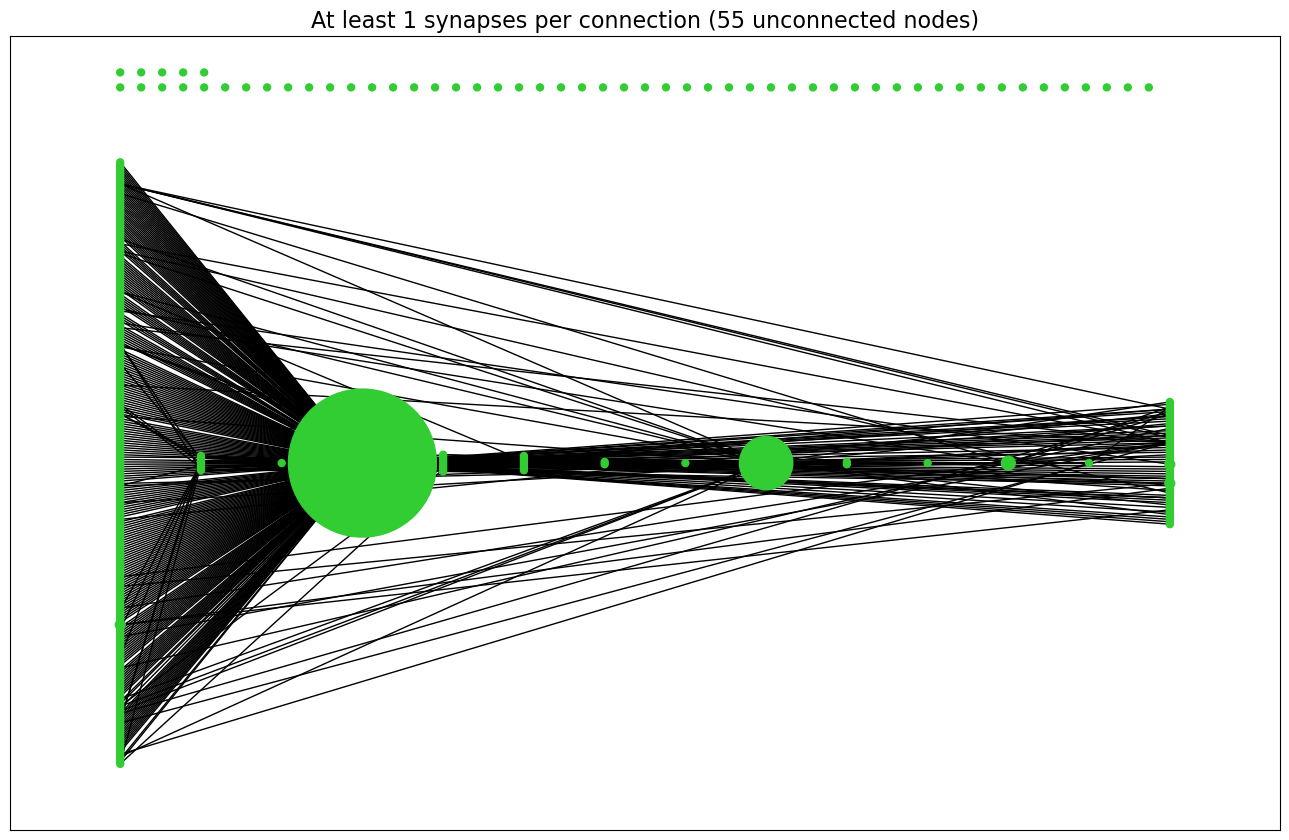

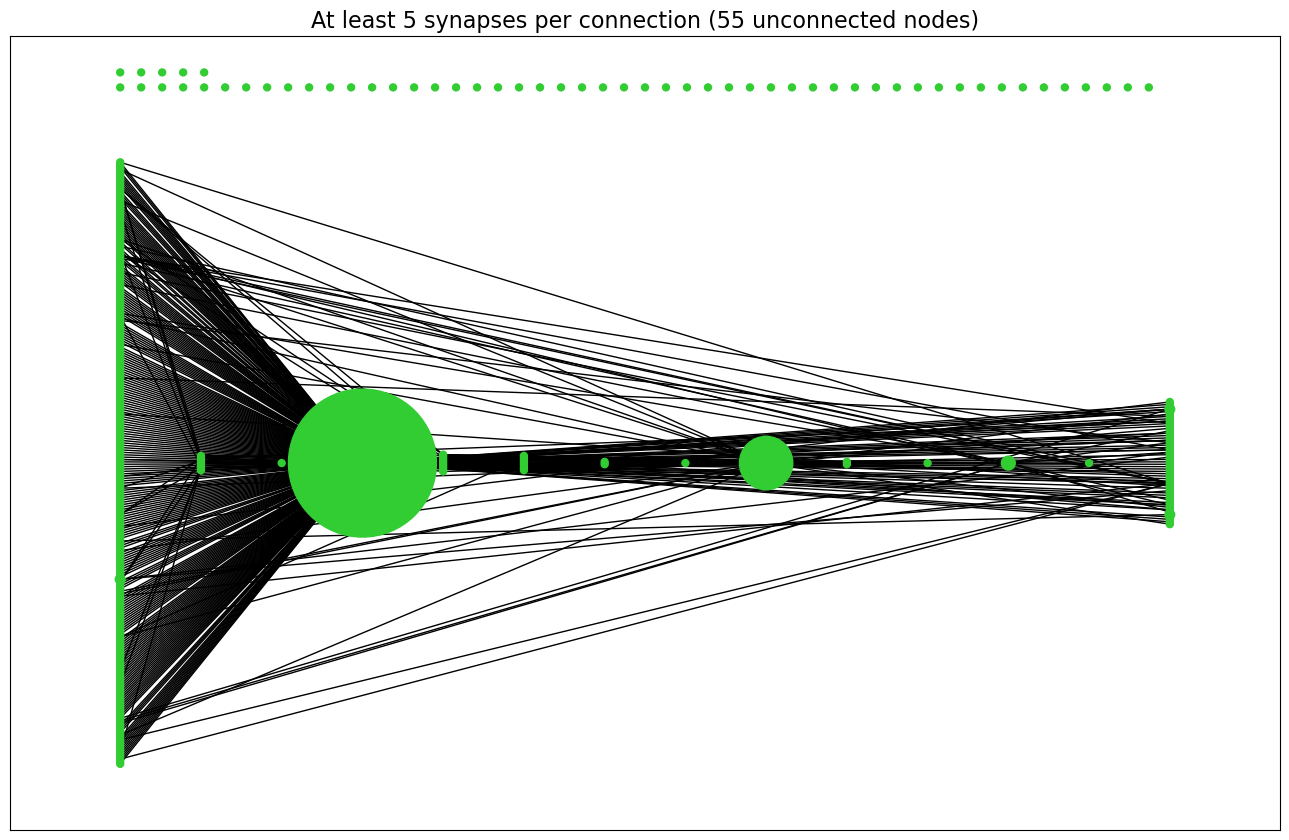

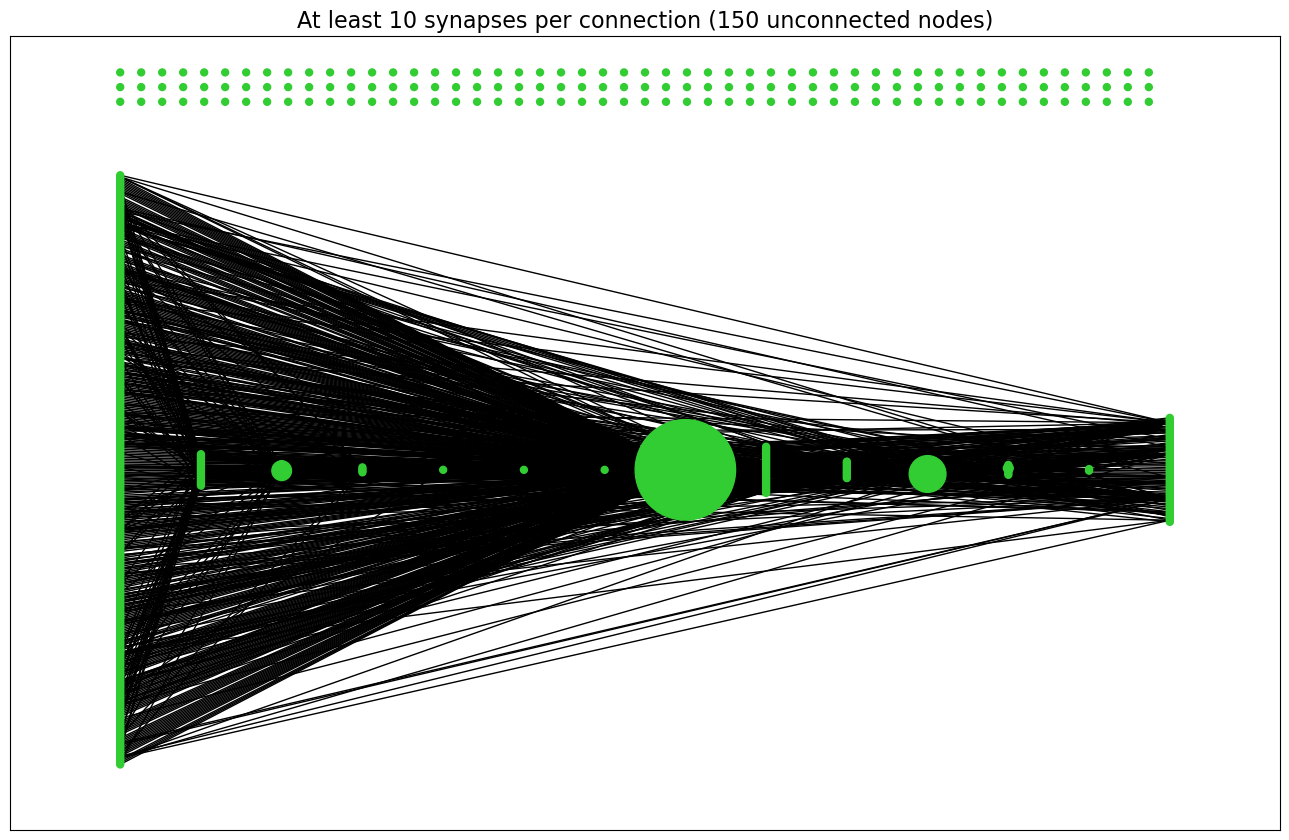

In [25]:
plt.show()

**I'm not sure what the point of this code block is. Looks like it's testing whether there is a reciprocal edge among random pairs of neurons in the graph. Maybe it was a sanity check.**

In [26]:
print(f'Largest SCC for min_syn = {min_syn}:')
print(list(scc_fly[np.argmax(alphs)]))

temp_true = []
temp_mostly_false = []

for u in np.random.choice(list(scc_fly[np.argmax(alphs)]), 50):
    for v in np.random.choice(list(scc_fly[np.argmax(alphs)]), 50):
        temp_true.append(nx.has_path(g_fly, u, v) and nx.has_path(g_fly, v, u))
        
for u in np.random.choice([i for i in range(493) if i not in scc_fly[np.argmax(alphs)]], 50):
    for v in np.random.choice([i for i in range(493) if i not in scc_fly[np.argmax(alphs)]], 50):
        temp_mostly_false.append(nx.has_path(g_fly, u, v) and nx.has_path(g_fly, v, u))
        
print(list(np.array(temp_true).astype(int)))
print(list(np.array(temp_mostly_false).astype(int)))

Largest SCC for min_syn = 10:
[5, 6, 7, 8, 10, 15, 16, 17, 531, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 564, 53, 52, 567, 56, 57, 58, 59, 60, 61, 62, 574, 63, 65, 66, 67, 580, 68, 70, 71, 69, 72, 74, 589, 77, 79, 80, 81, 82, 83, 596, 86, 87, 602, 606, 95, 608, 96, 98, 99, 19, 104, 107, 108, 109, 110, 111, 627, 123, 124, 130, 134, 136, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 182, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 203, 204, 205, 718, 206, 765, 767, 770, 54, 792, 283, 284, 288, 289, 291, 292, 805, 293, 295, 296, 297, 298, 817, 835, 863, 882, 388, 389, 390, 391, 392, 393, 394, 395, 396, 397, 398, 399, 400, 401, 402, 403, 404, 405, 406, 407, 408, 409, 411, 412, 430, 431, 492, 493, 494, 495, 505]
[

## Null model comparison

Erdos-Renyi

**If there isn't already an ER graph, they make it here (or several) and then run the hierarchical analyses on it. Same with the configuration model in the following code block. They plot histograms as line graphs in the last code block.**

In [ ]:
try:
    df_tfo_er = pd.read_csv('new_data/ER1_hierarchy_metrics.csv')
except:
    SEED = 0
    n_seed = 300
    n_neur = w.shape[0]
    #min_syns_rand = [1, 5, 10]

    ts_er_all = []
    fs_er_all = []
    os_er_all = []

    fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), tight_layout=True)

    for cms, min_syn in enumerate(min_syns_rand):
        adj_fly = (w >= min_syn)

        m_in = np.mean(np.sum(adj_fly, 0))
        m_out = np.mean(np.sum(adj_fly, 1))

        np.testing.assert_almost_equal(m_in, m_out)

        g_fly = nx.from_numpy_array(adj_fly, create_using=nx.DiGraph)
        node_list = list(g_fly.nodes())

        k_in = np.array([g_fly.in_degree()[v] for v in node_list])
        k_out = np.array([g_fly.out_degree()[v] for v in node_list])

        np.testing.assert_almost_equal(m_in, np.mean(k_in))
        np.testing.assert_almost_equal(m_out, np.mean(k_out))

        p_er = np.sum(adj_fly)/(n_neur*(n_neur-1))

        bins = np.arange(2 + np.max([np.max(k_in), np.max(k_out)])) - .5
        binc = .5*(bins[:-1] + bins[1:])
        cts_in = np.histogram(k_in, bins)[0]
        cts_out = np.histogram(k_out, bins)[0]

        axs[cms].plot(binc, cts_in, lw=3, c='g')
        axs[cms].plot(binc, cts_out, lw=3, c='k')

        if cms == 0:
            axs[cms].legend(['In-Degree', 'Out-Degree'])
        axs[cms].set_xlabel('# connections')
        axs[cms].set_ylabel('# neurons')
        axs[cms].set_title(f'{min_syn} synapses per connection')

        ts_er = []
        fs_er = []
        os_er = []

        sys.stdout.write(f'\nmin_syn = {min_syn}')
        for cs in range(n_seed):
            np.random.seed(cs + SEED)
            adj_er = np.random.rand(n_neur, n_neur) < p_er
            np.fill_diagonal(adj_er, 0)

            g_er = nx.from_numpy_array(adj_er, create_using=nx.DiGraph)

            gc_er, scc_er = get_gc(g_er)

            ts_er.append(calc_treeness(gc_er)[0])
            fs_er.append(calc_feedforwardness(gc_er))
            os_er.append(calc_orderability(gc_er))

            sys.stdout.write('.')

        ts_er_all.append(ts_er)
        fs_er_all.append(fs_er)
        os_er_all.append(os_er)

    set_font_size(axs, 16)
    
    dict_tfo_er = []

    for cms, min_syn in enumerate(min_syns_rand):
        dict_tfo_er.extend([
            {'min_syn': min_syn, 'trial': trial+1, 'treeness': t_er, 'feedforwardness': f_er, 'orderability': o_er}
            for trial, (t_er, f_er, o_er) in enumerate(zip(ts_er_all[cms], fs_er_all[cms], os_er_all[cms]))
        ])

    df_tfo_er = pd.DataFrame(columns=['min_syn', 'trial', 'treeness', 'feedforwardness', 'orderability'], data=dict_tfo_er)
    df_tfo_er.to_csv('new_data/ER1_hierarchy_metrics.csv', index=False)


min_syn = 1............................................................................................................................................................................................................................................................................................................
min_syn = 5............................................................................................................................................................................................................................................................................................................
min_syn = 10............................................................................................................................................................................................................................................................................................................

Configuration model

In [28]:
try:
    df_tfo_cm = pd.read_csv('new_data/CM1_hierarchy_metrics.csv')
except:
    SEED = 0
    n_seed = 300
    n_neur = w.shape[0]
    #min_syns_rand = [1, 5, 10]

    ts_cm_all = []
    fs_cm_all = []
    os_cm_all = []

    fig, axs = plt.subplots(1, 3, figsize=(12, 3.5), tight_layout=True)

    for cms, min_syn in enumerate(min_syns_rand):
        adj_fly = (w >= min_syn)

        m_in = np.mean(np.sum(adj_fly, 0))
        m_out = np.mean(np.sum(adj_fly, 1))

        np.testing.assert_almost_equal(m_in, m_out)

        g_fly = nx.from_numpy_array(adj_fly, create_using=nx.DiGraph)
        node_list = list(g_fly.nodes())

        k_in = np.array([g_fly.in_degree()[v] for v in node_list])
        k_out = np.array([g_fly.out_degree()[v] for v in node_list])

        np.testing.assert_almost_equal(m_in, np.mean(k_in))
        np.testing.assert_almost_equal(m_out, np.mean(k_out))

        bins = np.arange(2 + np.max([np.max(k_in), np.max(k_out)])) - .5
        binc = .5*(bins[:-1] + bins[1:])
        cts_in = np.histogram(k_in, bins)[0]
        cts_out = np.histogram(k_out, bins)[0]

        axs[cms].plot(binc, cts_in, lw=3, c='g')
        axs[cms].plot(binc, cts_out, lw=3, c='k')

        if cms == 0:
            axs[cms].legend(['In-Degree', 'Out-Degree'])
        axs[cms].set_xlabel('# connections')
        axs[cms].set_ylabel('# neurons')
        axs[cms].set_title(f'{min_syn} synapses per connection')

        ts_cm = []
        fs_cm = []
        os_cm = []

        gs_cm = []

        sys.stdout.write(f'\nmin_syn = {min_syn}')
        for cs in range(n_seed):
            np.random.seed(cs + SEED)

            g_cm = nx.directed_configuration_model(in_degree_sequence=k_in, out_degree_sequence=k_out)
            gs_cm.append(g_cm)

            gc_cm, scc_cm = get_gc(g_cm)

            ts_cm.append(calc_treeness(gc_cm)[0])
            fs_cm.append(calc_feedforwardness(gc_cm))
            os_cm.append(calc_orderability(gc_cm))

            sys.stdout.write('.')

        ts_cm_all.append(ts_cm)
        fs_cm_all.append(fs_cm)
        os_cm_all.append(os_cm)

    set_font_size(axs, 16)
    
    dict_tfo_cm = []

    for cms, min_syn in enumerate(min_syns_rand):
        dict_tfo_cm.extend([
            {'min_syn': min_syn, 'trial': trial+1, 'treeness': t_cm, 'feedforwardness': f_cm, 'orderability': o_cm}
            for trial, (t_cm, f_cm, o_cm) in enumerate(zip(ts_cm_all[cms], fs_cm_all[cms], os_cm_all[cms]))
        ])

    df_tfo_cm = pd.DataFrame(columns=['min_syn', 'trial', 'treeness', 'feedforwardness', 'orderability'], data=dict_tfo_cm)
    df_tfo_cm.to_csv('new_data/CM1_hierarchy_metrics.csv', index=False)


min_syn = 1............................................................................................................................................................................................................................................................................................................
min_syn = 5............................................................................................................................................................................................................................................................................................................
min_syn = 10............................................................................................................................................................................................................................................................................................................

In [29]:
bins_t = np.linspace(-1.05, 1.05, 101)
binc_t = .5*(bins_t[:-1] + bins_t[1:])
bins_f = np.linspace(-0.05, 1.05, 101)
binc_f = .5*(bins_f[:-1] + bins_f[1:])
bins_o = np.linspace(-0.05, 1.05, 101)
binc_o = .5*(bins_o[:-1] + bins_o[1:])

for cms, min_syn in enumerate(min_syns_rand):
    
    cts_t_er = np.histogram(df_tfo_er[df_tfo_er['min_syn']==min_syn]['treeness'], bins=bins_t)[0]
    cts_f_er = np.histogram(df_tfo_er[df_tfo_er['min_syn']==min_syn]['feedforwardness'], bins=bins_f)[0]
    cts_o_er = np.histogram(df_tfo_er[df_tfo_er['min_syn']==min_syn]['orderability'], bins=bins_o)[0]
    
    cts_t_cm = np.histogram(df_tfo_cm[df_tfo_cm['min_syn']==min_syn]['treeness'], bins=bins_t)[0]
    cts_f_cm = np.histogram(df_tfo_cm[df_tfo_cm['min_syn']==min_syn]['feedforwardness'], bins=bins_f)[0]
    cts_o_cm = np.histogram(df_tfo_cm[df_tfo_cm['min_syn']==min_syn]['orderability'], bins=bins_o)[0]
    
    fig, axs = plt.subplots(1, 3, figsize=(15, 4), tight_layout=True)
    
    axs[0].plot(binc_t, cts_t_er, c='gray', lw=3)
    axs[0].plot(binc_t, cts_t_cm, c='k', lw=3)
    axs[0].axvline(df_tfo_fly[df_tfo_fly['min_syn']==min_syn]['treeness'].iloc[0], lw=3, color='g')
    axs[0].axvline(1, color='c', ls='--', lw=3)
    axs[0].set_xlim(-1.05, 1.05)
    axs[0].set_xticks([-1, -.5, 0, .5, 1])
    axs[0].set_xlabel('T')
    axs[0].set_title(f'Treeness')
    
    axs[1].plot(binc_f, cts_f_er, c='gray', lw=3)
    axs[1].plot(binc_f, cts_f_cm, c='k', lw=3)
    axs[1].axvline(df_tfo_fly[df_tfo_fly['min_syn']==min_syn]['feedforwardness'].iloc[0], lw=3, color='g')
    axs[1].axvline(1, color='c', ls='--', lw=3)
    axs[1].set_xlim(-.05, 1.05)
    axs[1].set_xlabel('F')
    axs[1].set_title(f'Feedforwardness')
    axs[1].legend(['Fully random', 'Degree-matched\nrandom', 'Empirical', 'Max hierarchical'])
    
    axs[2].plot(binc_o, cts_o_er, c='gray', lw=3)
    axs[2].plot(binc_o, cts_o_cm, c='k', lw=3)
    axs[2].axvline(df_tfo_fly[df_tfo_fly['min_syn']==min_syn]['orderability'].iloc[0], lw=3, color='g')
    axs[2].axvline(1, color='c', ls='--', lw=3)
    axs[2].set_xlim(-.05, 1.05)
    axs[2].set_xlabel('O')
    axs[2].set_title(f'Orderability')
    
    for ax in axs:
        ax.set_ylabel('# trials')
        set_font_size(ax, 20, legend_font_size=16)
        
    fig.savefig(f'plots/tfo_min_syn_{min_syn}.png')

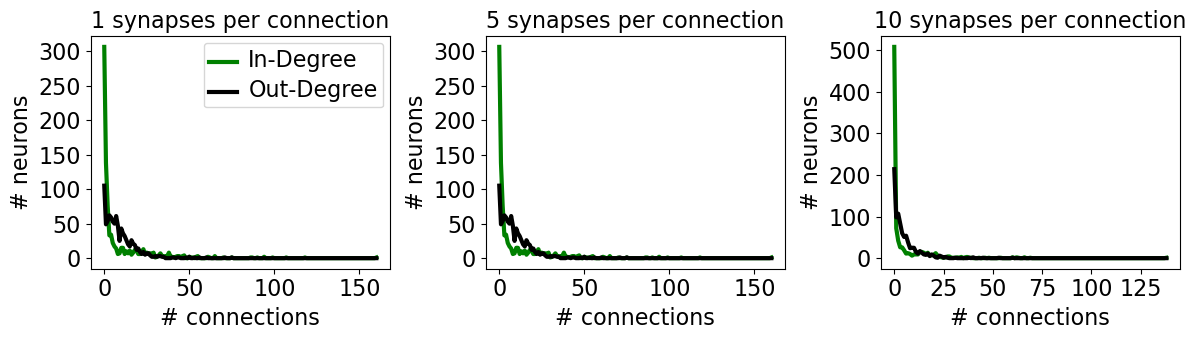

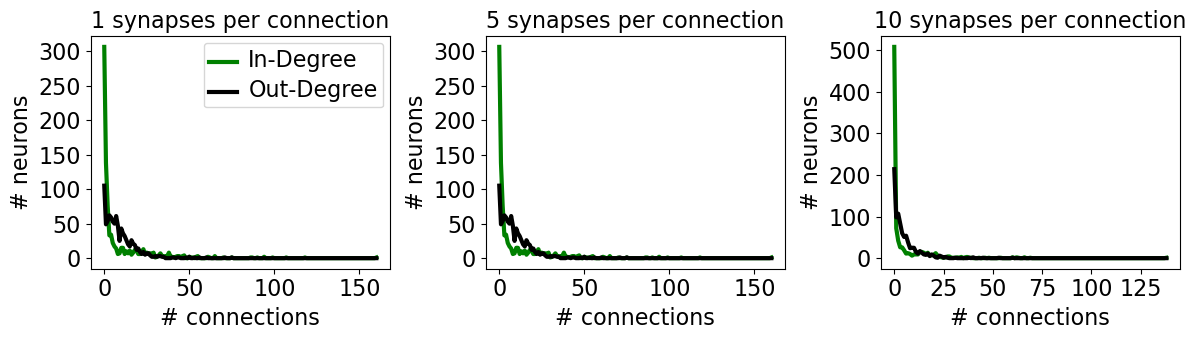

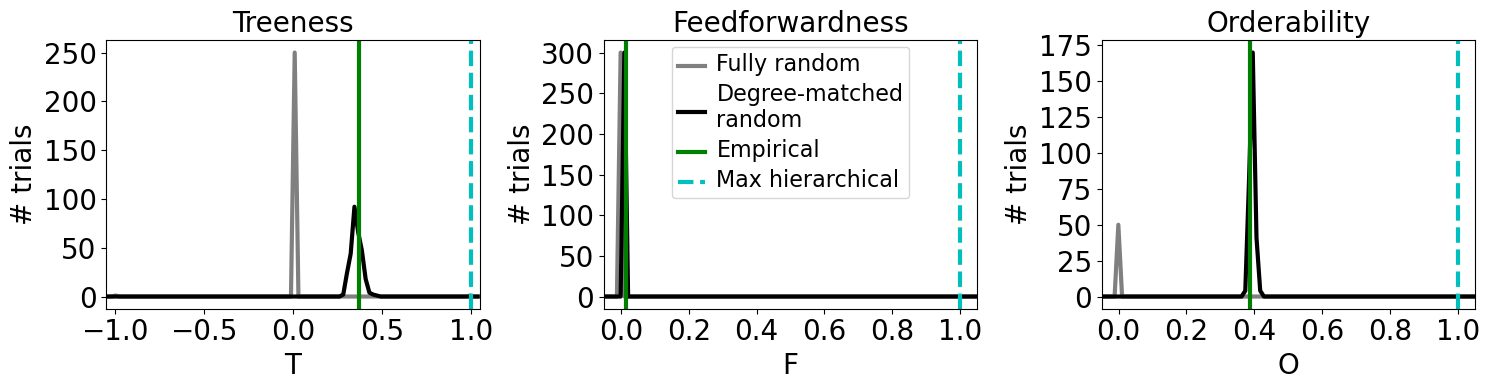

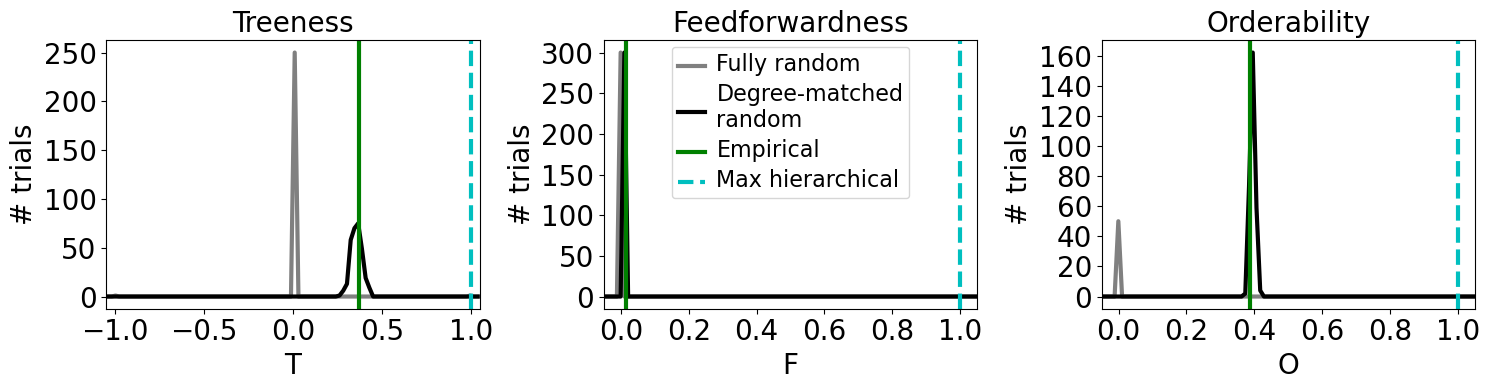

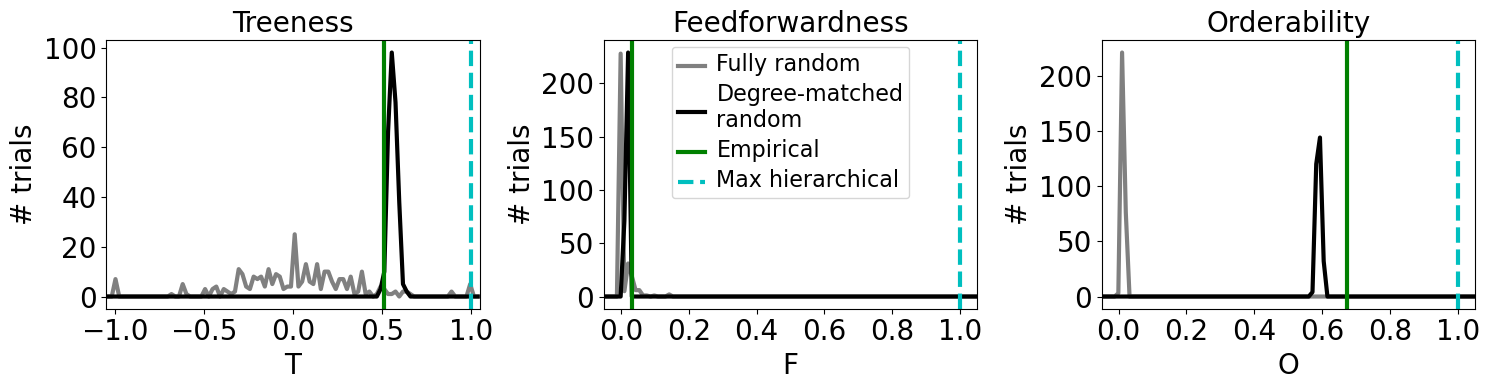

In [30]:
plt.show()